# 02 - Data Cleaning: Preparing the Suzuki Coupling Dataset for Modeling

### 🧹 Purpose of this Notebook

In [01_data_exploration](01_data_exploration.ipynb), we explored the raw Suzuki-Miyaura coupling dataset from **Perera et al. (*Science*, 2018)**. This exploration allowed us to gain a better understanding of the dataset but also to identify certain problems that need to be corrected before any modeling.

1. **Missing values** in `Ligand_Short_Hand`, `Ligand_eq`, and `Reagent_1_Short_Hand` - these are intentional experimental controls (reactions run without ligand or without base), not random data corruption.
2. **Constant columns** such as `Catalyst_1_Short_Hand` (always Pd(OAc)₂) that carry no predictive information.
3. **Useless columns** like `Product_Yield_Mass_Ion_Count` (weakly correlated with UV yield, r ≈ 0.35, furthermore, we have established that we will use UV yield for our model) and `Reactant_1_Name` (The short name column is sufficient to identify the chemical species.).
4. **Inconsistent column naming** more descriptive names will be given to the columns.
5. **Potential outliers** in the UV yield that could distort model training.

### 🎯 Goals

1. Encode missing values as explicit categories (`"None"`, `0.0`)
2. Drop constant and redundant columns
3. Removing THF_V2 rows
4. Rename columns for clarity and consistency
5. Detect and flag potential outliers in the target variable
6. Validate the cleaned dataset
7. Export to `data/processed/`

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the raw dataset
RAW_PATH = os.path.join("..", "data", "raw", "aap9112_data_file_s1.xlsx")
df = pd.read_excel(RAW_PATH)

print(f"Raw dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

## 1. Handling Missing Values

As demonstrated in [01_data_exploration](01_data_exploration.ipynb), the missing values ​​are not random or due to data corruption. They correspond to **intentional experiments**.


| Column | Missing count | Reason |
|---|---|---|
| `Ligand_Short_Hand` | 480 (8.3%) | Reactions run **without ligand** - testing if bare Pd(OAc)₂ can catalyze the coupling |
| `Ligand_eq` | 480 (8.3%) | Same rows - no ligand means no ligand equivalents |
| `Reagent_1_Short_Hand` | 720 (12.5%) | Reactions run **without base** - testing if transmetalation proceeds without base activation |

### Strategy

Since "no ligand" and "no base" are **meaningful experimental conditions**, we must not drop these rows or impute them with existing categories. Instead:
- **Categorical columns** (`Ligand_Short_Hand`, `Reagent_1_Short_Hand`): fill NaN with `"None"`, a value that our model can interpret as an intentional lack.
- **Numerical columns** (`Ligand_eq`, `Reagent_1_eq`): fill NaN and `2.5` with `0.0`, zero equivalents were added.

This encoding preserves the experimental design and allows the ML model to learn the effect of running reactions without these components.

In [ ]:
# Handle intentional missing values as explicit experimental conditions

# Keep track of missing values before cleaning
cols_to_check = ["Ligand_Short_Hand", "Ligand_eq", "Reagent_1_Short_Hand"]
print("Missing values before:")
print(df[cols_to_check].isna().sum())

# Rows run without ligand
no_ligand_mask = df["Ligand_Short_Hand"].isna()
df.loc[no_ligand_mask, "Ligand_Short_Hand"] = "None"
df.loc[no_ligand_mask, "Ligand_eq"] = 0.0

# Rows run without base
no_base_mask = df["Reagent_1_Short_Hand"].isna()
df.loc[no_base_mask, "Reagent_1_Short_Hand"] = "None"
df.loc[no_base_mask, "Reagent_1_eq"] = 0.0

# Safety fill for any remaining missing numeric equivalents
df["Ligand_eq"] = df["Ligand_eq"].fillna(0.0)
df["Reagent_1_eq"] = df["Reagent_1_eq"].fillna(0.0)

print("\nMissing values after:")
print(df[cols_to_check].isna().sum())

Missing values before:
Ligand_Short_Hand       480
Ligand_eq               480
Reagent_1_Short_Hand    720
dtype: int64

Missing values after:
Ligand_Short_Hand       0
Ligand_eq               0
Reagent_1_Short_Hand    0
dtype: int64


In [ ]:
# Check that "None" categories have corresponding equivalents set to 0.0 or None
ligand_mismatch = df[(df["Ligand_Short_Hand"] == "None") & (df["Ligand_eq"] != 0.0)]
base_mismatch = df[(df["Reagent_1_Short_Hand"] == "None") & (df["Reagent_1_eq"] != 0.0)]

# Summary of findings
print(f'Rows with Ligand == "None": {(df["Ligand_Short_Hand"] == "None").sum()}')
print(f'  Mismatches (Ligand_eq != 0.0): {len(ligand_mismatch)}')

print(f'\nRows with Base == "None": {(df["Reagent_1_Short_Hand"] == "None").sum()}')
print(f'  Mismatches (Reagent_1_eq != 0.0): {len(base_mismatch)}')

# Display mismatches if any
if len(ligand_mismatch) == 0 and len(base_mismatch) == 0:
    print("\n All corresponding equivalents are correctly set to 0.0.")
else:
    print("\n Found mismatches. Showing first rows:")
    display(ligand_mismatch.head())
    display(base_mismatch.head())

Rows with Ligand == "None": 480
  Mismatches (Ligand_eq != 0.0): 0

Rows with Base == "None": 720
  Mismatches (Reagent_1_eq != 0.0): 0

 All corresponding equivalents are correctly set to 0.0.


All missing values have been resolved. The `"None"` category now explicitly represents the absence of a ligand or base, and the corresponding equivalents are set to `0.0`.

## 2. Dropping Constant and Redundant Columns

Not all columns in the dataset are useful for the model. In this section, we will identify which columns are necessary for the model and which are not, and remove those that are constant (contribute nothing to the model) or redundant (duplicate information).

### 2.1 Constant columns

As stated previously, a constant column provides no information to the model. During the exploration in [01_data_exploration](01_data_exploration.ipynb), we found that the catalyst was constant (`Catalyst_1_Short_Hand` is always `Pd(OAc)₂`). Let's look at which other columns could potentially be constant.

In [ ]:
# Identify constant columns (only 1 unique value)
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("Constant columns (1 unique value):")
for col in constant_cols:
    print(f"  {col}: {df[col].unique()}")

Constant columns (1 unique value):
  Reactant_1_eq: [1]
  Reactant_1_mmol: [0.0004]
  Reactant_2_eq: [1]
  Catalyst_1_Short_Hand: <StringArray>
['Pd(OAc)2']
Length: 1, dtype: str
  Catalyst_1_eq: [0.0625]


This allows us to realize that the equivalents of the reactants and the catalyst are constant for each experiment. Furthermore, the quantity of reactant 1 in millimoles is also constant at 0.004. Finally, as stated earlier, the catalyst is always the same. These data can therefore be removed from the dataset.

### 2.2 Columns to drop

Based on the analysis above and the conclusions from Notebook 01, we drop the following columns:

| Column | Reason for removal |
|---|---|
| `Reaction_No` | Row identifier, not a feature. Will be preserved as the DataFrame index |
| `Reactant_1_Short_Hand` | Short chemical name, redundant with `Reactant_1_Name` |
| `Reactant_1_eq` | Constant equivalents for the first reactant, zero variance |
| `Reactant_2_eq` | Constant equivalents for the second reactant, zero variance |
| `Catalyst_1_Short_Hand` | Constant (`Pd(OAc)₂`) across all reactions, zero variance |
| `Catalyst_1_eq` | Constant equivalents for the single catalyst, zero variance |
| `Reactant_1_mmol` | Absolute quantity in mmol, since `Reactant_1_eq` (equivalents) is already present and equivalents are the chemically meaningful unit for stoichiometry, mmol is redundant |
| `Product_Yield_Mass_Ion_Count` | MS-based yield, weakly correlated with UV yield (r ≈ 0.35), unreliable for regression |

In [ ]:
# Drop redundant / constant / unreliable columns
cols_to_drop = [
    "Reaction_No",            # Not useful for modeling
    "Reactant_1_Short_Hand",    # Redundant with short-hand
    "Reactant_1_eq",            # Redundant with equivalents
    "Reactant_2_eq",            # Redundant with equivalents
    "Catalyst_1_Short_Hand",    # Constant: Pd(OAc)₂
    "Catalyst_1_eq",            # Constant equivalents
    "Reactant_1_mmol",          # Redundant with equivalents
    "Product_Yield_Mass_Ion_Count",  # Unreliable MS yield
]

df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns.")
print(f"Remaining shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nRemaining columns:\n{list(df.columns)}")

Dropped 8 columns.
Remaining shape: 5760 rows × 8 columns

Remaining columns:
['Reactant_1_Name', 'Reactant_2_Name', 'Ligand_Short_Hand', 'Ligand_eq', 'Reagent_1_Short_Hand', 'Reagent_1_eq', 'Solvent_1_Short_Hand', 'Product_Yield_PCT_Area_UV']


## 3. Removing THF_V2 Rows

As identified in [01_data_exploration](01_data_exploration.ipynb), the dataset contains two entries for THF-based solvents (`THF` and `THF_V2`) despite identical chemical structures. And a **12% median yield difference** was observed.

Since merging them would hide this artifact and keeping both would introduce inconsistency, the 96 `THF_V2` rows are **removed**. This represents a loss of only ~1.7% of the dataset, which is acceptable.

In [ ]:
# Remove THF_V2 rows (batch inconsistency identified in exploration)
n_before = len(df)
df = df[df["Solvent_1_Short_Hand"] != "THF_V2"].copy()
n_removed = n_before - len(df)

print(f"Removed {n_removed} THF_V2 rows.")
print(f"Remaining dataset: {len(df)} rows")

## 4. Renaming Columns for Consistency

We will rename the columns to have simpler and more explicit names.

In [ ]:
# Rename columns
rename_map = {
    "Reactant_1_Name":            "reactant_1",
    "Reactant_2_Name":            "reactant_2",
    "Ligand_Short_Hand":          "ligand",
    "Ligand_eq":                  "ligand_eq",
    "Reagent_1_Short_Hand":       "base",
    "Reagent_1_eq":               "base_eq",
    "Solvent_1_Short_Hand":       "solvent",
    "Product_Yield_PCT_Area_UV":  "yield_uv",
}

df = df.rename(columns=rename_map)

print(f"\nFinal columns: {list(df.columns)}")


Final columns: ['reactant_1', 'reactant_2', 'ligand', 'ligand_eq', 'base', 'base_eq', 'solvent', 'yield_uv']


In [ ]:
# Verify the cleaned DataFrame
df.head(15)

,reactant_1,reactant_2,ligand,ligand_eq,base,base_eq,solvent,yield_uv
0,6-chloroquinoline,"2a, Boronic Acid",P(tBu)3,0.125,NaOH,2.5,MeCN,4.764109
1,6-chloroquinoline,"2a, Boronic Acid",P(Ph)3,0.125,NaOH,2.5,MeCN,4.120962
2,6-chloroquinoline,"2a, Boronic Acid",AmPhos,0.125,NaOH,2.5,MeCN,2.583837
3,6-chloroquinoline,"2a, Boronic Acid",P(Cy)3,0.125,NaOH,2.5,MeCN,4.443171
4,6-chloroquinoline,"2a, Boronic Acid",P(o-Tol)3,0.125,NaOH,2.5,MeCN,1.949874
5,6-chloroquinoline,"2a, Boronic Acid",CataCXium A,0.125,NaOH,2.5,MeCN,3.250809
6,6-chloroquinoline,"2a, Boronic Acid",SPhos,0.125,NaOH,2.5,MeCN,86.262122
7,6-chloroquinoline,"2a, Boronic Acid",dtbpf,0.125,NaOH,2.5,MeCN,7.546080
8,6-chloroquinoline,"2a, Boronic Acid",XPhos,0.125,NaOH,2.5,MeCN,93.674515
9,6-chloroquinoline,"2a, Boronic Acid",dppf,0.125,NaOH,2.5,MeCN,14.321435


## 5. Outlier Detection in the Target Variable

Outliers in the target variable (`yield_uv`) can have a disproportionate effect on model training, especially for regression models that minimize squared error (e.g., linear regression, neural networks). We need to check for:

1. **Physically impossible values**: yields below 0% or above 100% would indicate measurement errors.
2. **Extreme but plausible values**: very high yields (>95%) or yields of exactly 0% that might reflect failed experiments rather than true zero-yield conditions.

### 5.1 Boundary check

Since `yield_uv` represents a percentage area from HPLC-UV, valid values should lie within the **[0, 100]** range. Any value outside this range would indicate a data quality issue.

In [ ]:
# Check for out-of-range yields
n_negative = (df["yield_uv"] < 0).sum()
n_over_100 = (df["yield_uv"] > 100).sum()

print(f"Yields < 0%:   {n_negative}")
print(f"Yields > 100%: {n_over_100}")
print(f"\nYield range: [{df['yield_uv'].min():.2f}, {df['yield_uv'].max():.2f}]")

Yields < 0%:   0
Yields > 100%: 0

Yield range: [0.00, 100.00]


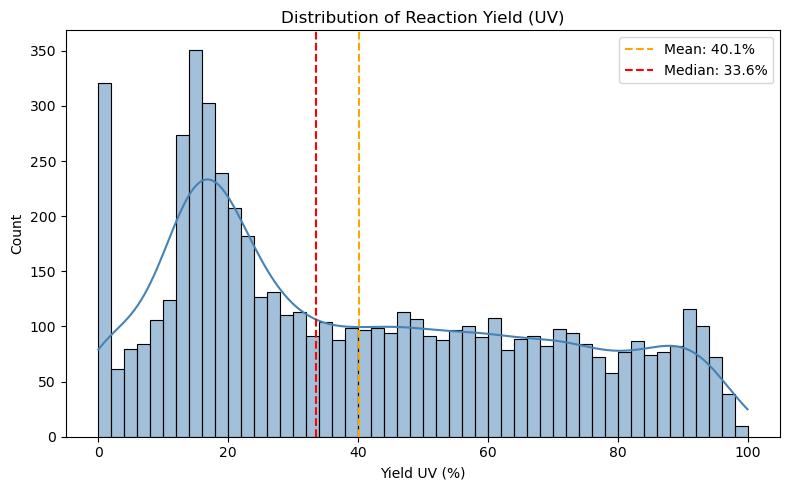

In [ ]:
# Plot the distribution of the target variable: yield_uv
plt.figure(figsize=(8, 5))
sns.histplot(df["yield_uv"], bins=50, kde=True, color="steelblue")

plt.axvline(df["yield_uv"].mean(), color="orange", linestyle="--", label=f"Mean: {df['yield_uv'].mean():.1f}%")
plt.axvline(df["yield_uv"].median(), color="red", linestyle="--", label=f"Median: {df['yield_uv'].median():.1f}%")

plt.title("Distribution of Reaction Yield (UV)")
plt.xlabel("Yield UV (%)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Decision on outliers

**Key observations:**
- **No physically impossible values**: all yields fall within the [0, 100] range, which is reassuring about the data collection quality from the HTE platform.
- **Right-skewed distribution**: the distribution shows a strong concentration of low-yield reactions (near 0%) and a long tail toward higher yields. Moreover, the median is lower than the mean, reflecting the large number of failed experiments.
- **Low-yield reactions are not outliers**: they represent genuinely failed experiments (incompatible conditions). Removing them would bias the model toward predicting only successful reactions.

**Decision: No rows are removed.** The full dataset of 5 760 reactions is retained. The model must learn to predict both high and low yields, as this is essential for recommending optimal reaction conditions in practice.

## 6. Export Cleaned Dataset

We save the cleaned dataset to `data/processed/` in CSV format for use in the next notebooks. CSV is chosen for portability and easy inspection.

In [ ]:
# Define the output path and ensure the folder exists
OUTPUT_DIR = os.path.join("..", "data", "processed")
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(OUTPUT_DIR, "suzuki_cleaned.csv")

# Save the cleaned dataset to the processed folder
df.to_csv(OUTPUT_PATH, index=False)

print(f"Cleaned dataset saved to: {OUTPUT_PATH}")

Cleaned dataset saved to: ..\data\processed\suzuki_cleaned.csv


## 7. Summary of Cleaning Operations

| Step | Operation | Detail | Rows affected |
|---|---|---|---|
| **Missing values** | Fill NaN → `"None"` / `0.0` | Ligand and Base encoded as explicit "absent" categories | 480 + 720 rows |
| **Index** | `Reaction_No` → DataFrame index | Preserved as identifier, removed from feature space | All |
| **Drop columns** | Removed 5 columns | `Reactant_1_Short_Hand`, `Catalyst_1_Short_Hand`, `Catalyst_1_eq`, `Reactant_1_mmol`, `Product_Yield_Mass_Ion_Count` | - |
| **Drop constant eq** | Removed constant equivalents | Columns with a single unique value carry no information | - |
| **THF_V2 removal** | Dropped 96 rows | 12% yield gap vs THF despite identical molecule | 96 rows |
| **Rename** | Standardized all column names | Short and explicit | - |
| **Outliers** | Checked, no removal | All yields within [0, 100]%; low yields are valid failed experiments | 0 |
| **Export** | Saved to CSV | `data/processed/suzuki_cleaned.csv` | - |

### Cleaned dataset schema

| Column | Type | Description |
|---|---|---|
| `reactant_1` | categorical | Short-hand name of the electrophile (aryl halide) |
| `reactant_2` | categorical | Name of the nucleophile (organoboron species) |
| `ligand` | categorical | Phosphine ligand name (`"None"` = no ligand) |
| `ligand_eq` | float | Equivalents of ligand (`0.0` = no ligand) |
| `base` | categorical | Base name (`"None"` = no base) |
| `base_eq` | float | Equivalents of the base |
| `solvent` | categorical | Solvent short-hand name |
| **`yield_uv`** | **float** | **Target variable → HPLC-UV yield (%)** |

### Next Steps (Notebook 03 - Feature Engineering)
1. Generate **molecular descriptors** (molecular weight, logP, TPSA, etc.) from SMILES for each reactant, ligand, base, and solvent using RDKit
2. Compute **molecular fingerprints** (Morgan/ECFP) as numerical representations of molecular structure
3. Encode categorical features (one-hot encoding or target encoding) if fingerprints are not used
4. Scale numerical features for models that require it (e.g., neural networks)
5. Train/test split with stratification on yield bins